# 02 · Exploratory Analysis: Sales Trends

This notebook answers the "how is revenue trending?" part of the brief. It uses all valid sales,
**including guest orders**, because they're real revenue even without a Customer ID.

Questions:
- How does revenue move month to month, and how strong is the Christmas peak?
- Which products and countries drive the business?
- When do customers place orders?
- What does a typical order look like?

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates

from style import BLUE, ORANGE, GREY, DARK_BLUE, TEXT_MUTED, BLUE_RAMP, GBP, set_style, save_fig, titles

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)

registered = pd.read_csv("../data/processed/clean.csv", parse_dates=["InvoiceDate"], dtype={"Invoice": str, "StockCode": str})
guests = pd.read_csv("../data/processed/guest_orders.csv", parse_dates=["InvoiceDate"], dtype={"Invoice": str, "StockCode": str})

sales = pd.concat([registered.assign(CustomerType="Registered"),
                   guests.assign(CustomerType="Guest")], ignore_index=True)
print(f"{len(sales):,} sale lines, {sales.Invoice.nunique():,} orders, total revenue £{sales.Revenue.sum():,.0f}")

997,160 sale lines, 39,251 orders, total revenue £19,042,338


## 1. Monthly revenue trend

The data stops on **9 December 2011**, so December 2011 only has nine days of trading. Plotted as
a normal month it looks like a crash, so I leave it out of the trend line. Everything else is a
full calendar month (Dec 2009 to Nov 2011, 24 months).

In [2]:
monthly = (sales.groupby(sales.InvoiceDate.dt.to_period("M"))
                .agg(Revenue=("Revenue", "sum"), Orders=("Invoice", "nunique"), Customers=("CustomerID", "nunique")))
monthly = monthly.loc[:"2011-11"]          # drop the partial December 2011
monthly["Rolling3"] = monthly["Revenue"].rolling(3).mean()
monthly.index = monthly.index.to_timestamp()

# Compare the two full trading years: Dec 2009-Nov 2010 vs Dec 2010-Nov 2011
year1 = monthly.loc["2009-12":"2010-11", "Revenue"].sum()
year2 = monthly.loc["2010-12":"2011-11", "Revenue"].sum()
print(f"Dec 2009-Nov 2010: £{year1:,.0f}")
print(f"Dec 2010-Nov 2011: £{year2:,.0f}  ({year2 / year1 - 1:+.1%})")

# How much of each year's revenue lands in Sep-Nov?
q4_share = {}
for label, (start, end) in {"2010": ("2009-12", "2010-11"), "2011": ("2010-12", "2011-11")}.items():
    yr = monthly.loc[start:end, "Revenue"]
    q4_share[label] = yr[yr.index.month.isin([9, 10, 11])].sum() / yr.sum()
    print(f"Sep-Nov share of trading year ending Nov {label}: {q4_share[label]:.1%}")

monthly[["Revenue", "Orders", "Customers"]].tail(13)

Dec 2009-Nov 2010: £9,218,894
Dec 2010-Nov 2011: £9,378,311  (+1.7%)
Sep-Nov share of trading year ending Nov 2010: 36.0%
Sep-Nov share of trading year ending Nov 2011: 37.6%


,Revenue,Orders,Customers
InvoiceDate,,,
2010-11-01,"1,398,451.58",2701,1601
2010-12-01,"766,924.53",1542,883
2011-01-01,"564,732.93",1073,737
2011-02-01,"504,714.91",1088,756
2011-03-01,"682,306.56",1431,970
2011-04-01,"509,523.35",1225,848
2011-05-01,"732,637.54",1652,1051
2011-06-01,"690,041.68",1511,986
2011-07-01,"682,545.01",1445,945


saved 01_monthly_revenue_trend.png


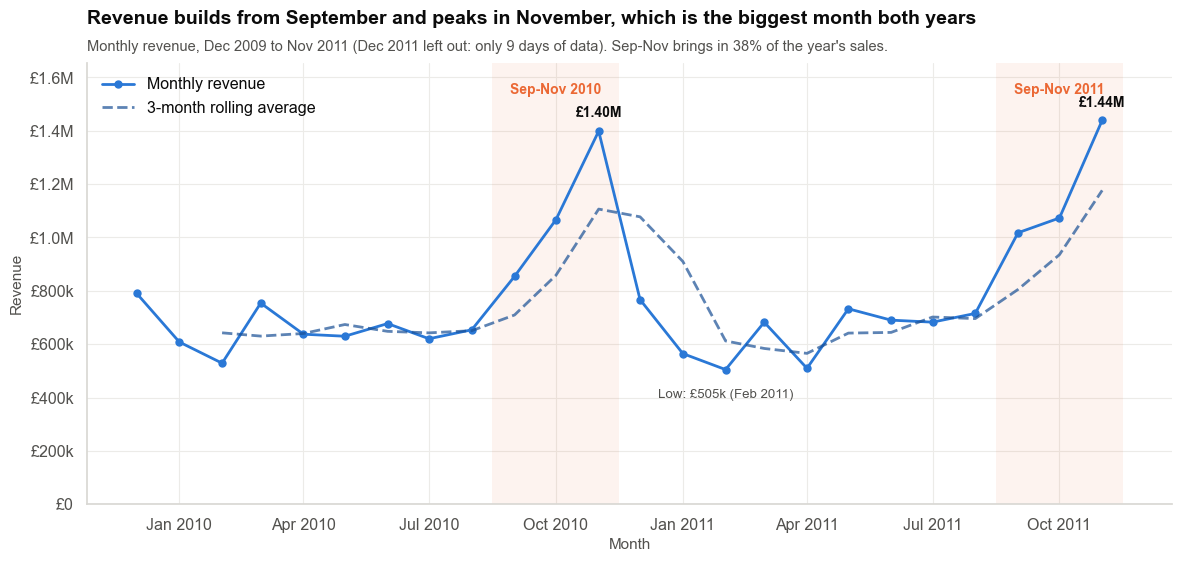

In [3]:
peak_month = monthly["Revenue"].idxmax()
low_month = monthly["Revenue"].idxmin()

fig, ax = plt.subplots(figsize=(12, 5.8))

# Shade Sep-Nov in each year to show the build-up to Christmas
for year in (2010, 2011):
    ax.axvspan(pd.Timestamp(f"{year}-08-16"), pd.Timestamp(f"{year}-11-16"), color=ORANGE, alpha=0.08, lw=0)
    ax.text(pd.Timestamp(f"{year}-10-01"), monthly.Revenue.max() * 1.07, f"Sep-Nov {year}",
            ha="center", color=ORANGE, fontsize=10, fontweight="bold")

ax.plot(monthly.index, monthly.Revenue, color=BLUE, lw=2, marker="o", ms=5, label="Monthly revenue")
ax.plot(monthly.index, monthly.Rolling3, color=DARK_BLUE, lw=2, ls="--", alpha=0.7, label="3-month rolling average")

# Label the two November peaks and the low point
for month in [pd.Timestamp("2010-11-01"), pd.Timestamp("2011-11-01")]:
    v = monthly.loc[month, "Revenue"]
    ax.annotate(f"£{v / 1e6:.2f}M", (month, v), xytext=(0, 10), textcoords="offset points",
                ha="center", fontsize=10, fontweight="bold")
v = monthly.loc[low_month, "Revenue"]
ax.annotate(f"Low: £{v / 1e3:.0f}k ({low_month:%b %Y})", (low_month, v), xytext=(0, -20),
            textcoords="offset points", ha="center", fontsize=9.5, color=TEXT_MUTED)

ax.yaxis.set_major_formatter(GBP)
ax.set_ylim(0, monthly.Revenue.max() * 1.15)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.legend(loc="upper left")
titles(ax, f"Revenue builds from September and peaks in November, which is the biggest month both years",
       f"Monthly revenue, Dec 2009 to Nov 2011 (Dec 2011 left out: only 9 days of data). "
       f"Sep-Nov brings in {q4_share['2011']:.0%} of the year's sales.")
fig.tight_layout()
save_fig(fig, "01_monthly_revenue_trend")
plt.show()

## 2. Top products

In [4]:
# Group by StockCode, not Description: some products have slightly different descriptions over
# time (e.g. "RETROSPOT" vs "RETRO SPOT"), which would split them into two rows.
names = sales.groupby("StockCode")["Description"].agg(lambda d: d.mode().iat[0])
products = (sales.groupby("StockCode")
                 .agg(Revenue=("Revenue", "sum"), Quantity=("Quantity", "sum"), Orders=("Invoice", "nunique")))
products.index = products.index.map(names)
top_rev = products.nlargest(10, "Revenue")
top_qty = products.nlargest(10, "Quantity")

top10_share = top_rev.Revenue.sum() / products.Revenue.sum()
print(f"{len(products):,} distinct products. Top 10 by revenue = {top10_share:.1%} of all revenue.")
print("In both top-10 lists:", sorted(set(top_rev.index) & set(top_qty.index)))
top_rev

4,716 distinct products. Top 10 by revenue = 7.6% of all revenue.
In both top-10 lists: ['ASSORTED COLOUR BIRD ORNAMENT', 'JUMBO BAG RED RETROSPOT', 'SMALL POPCORN HOLDER', 'WHITE HANGING HEART T-LIGHT HOLDER']


,Revenue,Quantity,Orders
StockCode,,,
REGENCY CAKESTAND 3 TIER,"322,576.57",25781,3807
WHITE HANGING HEART T-LIGHT HOLDER,"252,527.08",91356,5431
JUMBO BAG RED RETROSPOT,"181,069.75",96268,3996
PARTY BUNTING,"147,459.98",28002,2663
ASSORTED COLOUR BIRD ORNAMENT,"128,653.51",79632,2800
PAPER CHAIN KIT 50'S CHRISTMAS,"116,666.54",34659,2007
CHILLI LIGHTS,"80,079.38",15735,1129
SMALL POPCORN HOLDER,"79,347.30",88265,2318
JUMBO BAG PINK POLKADOT,"75,513.58",38984,2236


saved 02_top_products.png


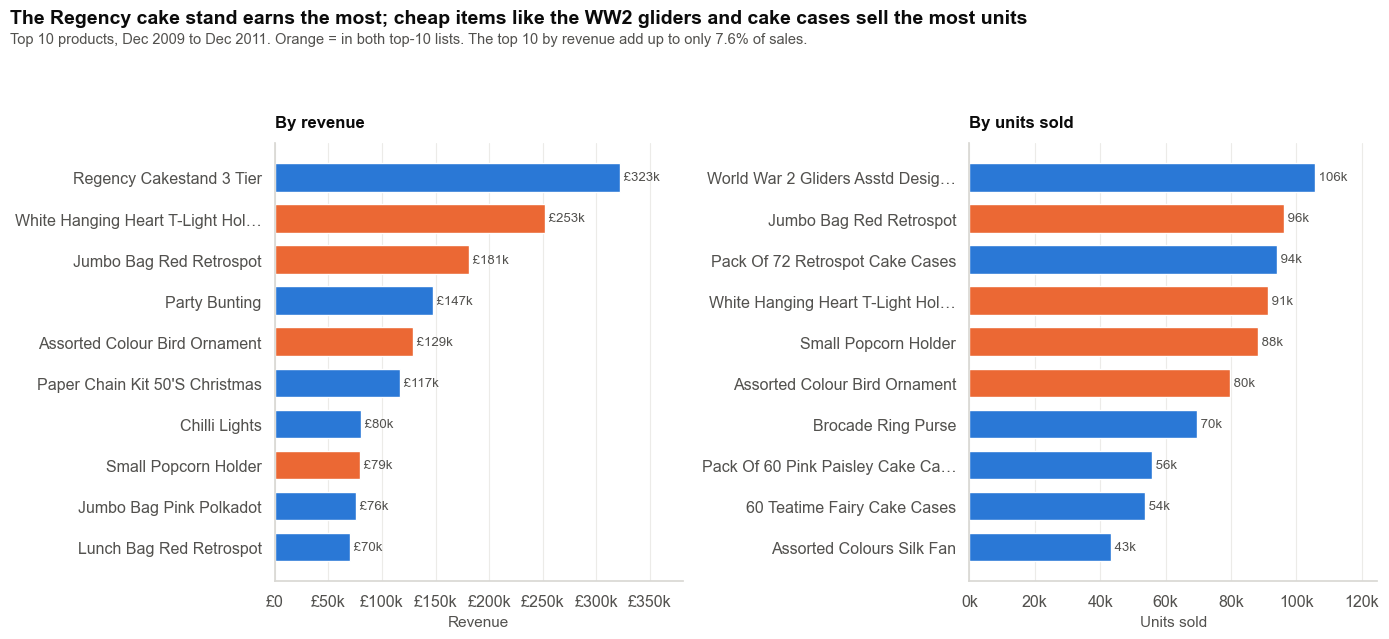

In [5]:
def short(label, n=32):
    """Title-case and trim long product names so bar labels stay readable."""
    label = label.title()
    return label if len(label) <= n else label[: n - 1] + "…"


both = set(top_rev.index) & set(top_qty.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 6.2))
for ax, data, col, fmt, xlabel in [
    (axes[0], top_rev, "Revenue", lambda v: f"£{v / 1e3:,.0f}k", "Revenue"),
    (axes[1], top_qty, "Quantity", lambda v: f"{v / 1e3:,.0f}k", "Units sold"),
]:
    data = data.sort_values(col)
    colors = [ORANGE if d in both else BLUE for d in data.index]
    ax.barh([short(d) for d in data.index], data[col], color=colors, height=0.7)
    for i, v in enumerate(data[col]):
        ax.text(v, i, " " + fmt(v), va="center", fontsize=9.5, color=TEXT_MUTED)
    ax.set_xlabel(xlabel)
    ax.xaxis.set_major_formatter(GBP if col == "Revenue" else plt.FuncFormatter(lambda x, _: f"{x / 1e3:.0f}k"))
    ax.set_xlim(0, data[col].max() * 1.18)
    ax.grid(axis="y", visible=False)
axes[0].set_title("By revenue", fontsize=12, loc="left")
axes[1].set_title("By units sold", fontsize=12, loc="left")

fig.suptitle(f"The Regency cake stand earns the most; cheap items like the WW2 gliders and cake cases sell the most units",
             x=0.01, y=1.03, ha="left", fontsize=14, fontweight="bold")
fig.text(0.01, 0.975, f"Top 10 products, Dec 2009 to Dec 2011. Orange = in both top-10 lists. "
         f"The top 10 by revenue add up to only {top10_share:.1%} of sales.", ha="left", fontsize=10.5, color=TEXT_MUTED)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "02_top_products")
plt.show()

## 3. Countries: the UK vs everyone else

In [6]:
countries = sales.groupby("Country").agg(Revenue=("Revenue", "sum"), Customers=("CustomerID", "nunique"),
                                         Orders=("Invoice", "nunique"))
countries["Share"] = countries.Revenue / countries.Revenue.sum()
countries = countries.sort_values("Revenue", ascending=False)

uk_share = countries.loc["United Kingdom", "Share"]
intl = countries.drop("United Kingdom")
print(f"UK share of revenue: {uk_share:.1%}. {len(intl)} other countries share the remaining {1 - uk_share:.1%}.")
print(f"Top 10 international countries = {intl.head(10).Revenue.sum() / intl.Revenue.sum():.1%} of non-UK revenue")

# Revenue per customer: international accounts tend to be bigger buyers
countries["RevenuePerCustomer"] = countries.Revenue / countries.Customers
countries.head(10)

UK share of revenue: 85.4%. 42 other countries share the remaining 14.6%.
Top 10 international countries = 85.7% of non-UK revenue


,Revenue,Customers,Orders,Share,RevenuePerCustomer
Country,,,,,
United Kingdom,"16,266,203.91",5326,35959,0.85,"3,054.11"
EIRE,"606,336.66",3,576,0.03,"202,112.22"
Netherlands,"546,262.53",22,214,0.03,"24,830.12"
Germany,"379,977.15",107,752,0.02,"3,551.19"
France,"296,034.08",93,595,0.02,"3,183.16"
Australia,"166,769.80",15,86,0.01,"11,117.99"
Switzerland,"93,323.61",22,82,0.00,"4,241.98"
Spain,"85,092.83",38,141,0.00,"2,239.28"
Sweden,"84,523.74",19,98,0.00,"4,448.62"


saved 03_top_countries.png


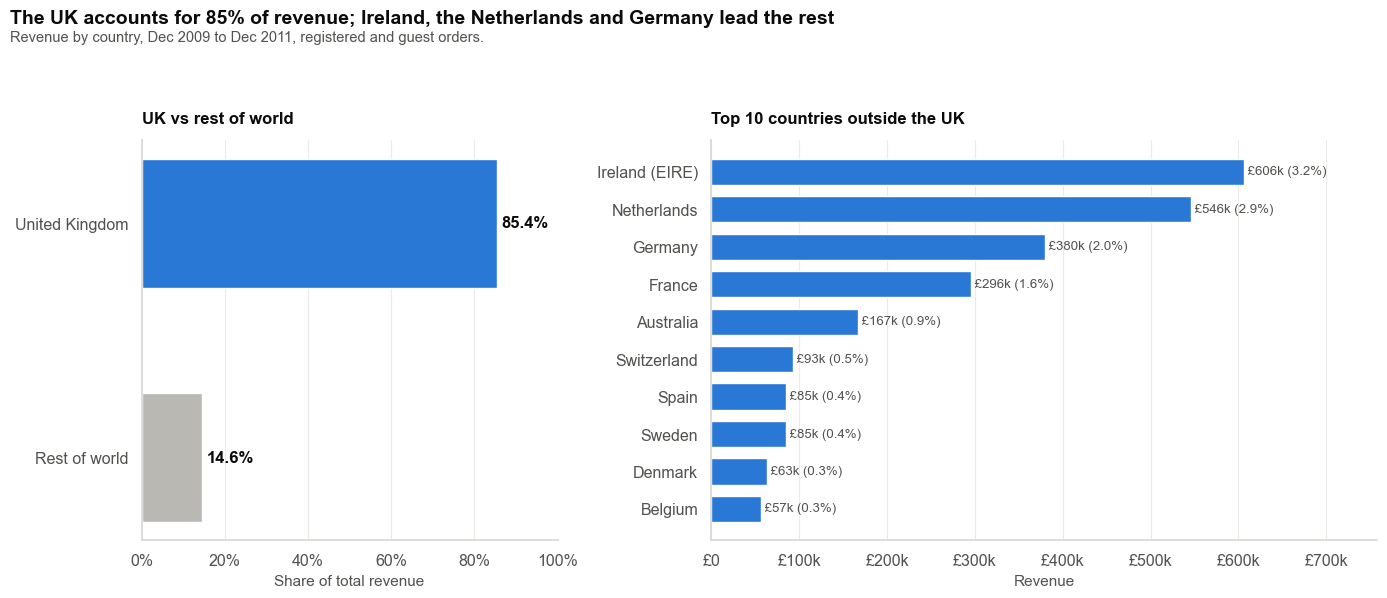

In [7]:
top10 = countries.head(10).sort_values("Revenue")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1, 1.6]})

# Left: UK vs rest of world
ax = axes[0]
split = pd.Series({"Rest of world": 1 - uk_share, "United Kingdom": uk_share})
ax.barh(split.index, split.values, color=[GREY, BLUE], height=0.55)
for i, v in enumerate(split.values):
    ax.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=12, fontweight="bold")
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Share of total revenue")
ax.grid(axis="y", visible=False)
ax.set_title("UK vs rest of world", fontsize=12, loc="left")

# Right: top 10 countries outside the UK
ax = axes[1]
top_intl = intl.head(10).sort_values("Revenue").rename(index={"EIRE": "Ireland (EIRE)"})
ax.barh(top_intl.index, top_intl.Revenue, color=BLUE, height=0.7)
for i, (v, s) in enumerate(zip(top_intl.Revenue, top_intl.Share)):
    ax.text(v, i, f" £{v / 1e3:,.0f}k ({s:.1%})", va="center", fontsize=9.5, color=TEXT_MUTED)
ax.xaxis.set_major_formatter(GBP)
ax.set_xlim(0, top_intl.Revenue.max() * 1.25)
ax.set_xlabel("Revenue")
ax.grid(axis="y", visible=False)
ax.set_title("Top 10 countries outside the UK", fontsize=12, loc="left")

fig.suptitle(f"The UK accounts for {uk_share:.0%} of revenue; Ireland, the Netherlands and Germany lead the rest",
             x=0.01, y=1.03, ha="left", fontsize=14, fontweight="bold")
fig.text(0.01, 0.975, "Revenue by country, Dec 2009 to Dec 2011, registered and guest orders.",
         ha="left", fontsize=10.5, color=TEXT_MUTED)
fig.tight_layout(rect=(0, 0, 1, 0.95))
save_fig(fig, "03_top_countries")
plt.show()

## 4. When do people order?

I count distinct orders (invoices) for each weekday and hour, not line items, so that a 100-line
wholesale order counts the same as a 2-line one.

In [8]:
DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

orders = sales.drop_duplicates("Invoice")[["Invoice", "InvoiceDate", "Weekday", "Hour"]]
heat = (orders.pivot_table(index="Weekday", columns="Hour", values="Invoice", aggfunc="count")
              .reindex(DAYS).fillna(0).astype(int))

print("Orders by weekday:")
print(orders.Weekday.value_counts().reindex(DAYS).fillna(0).astype(int).to_string())
busiest = heat.stack().idxmax()
print(f"Busiest slot: {busiest[0]} {busiest[1]}:00 with {heat.stack().max():,} orders")
midday = orders.Hour.between(10, 15).mean()
print(f"Orders placed 10:00-15:59: {midday:.1%}")

Orders by weekday:
Weekday
Monday       6200
Tuesday      7096
Wednesday    7074
Thursday     8105
Friday       5941
Saturday       30
Sunday       4805
Busiest slot: Wednesday 12:00 with 1,201 orders
Orders placed 10:00-15:59: 78.2%


saved 04_weekday_hour_heatmap.png


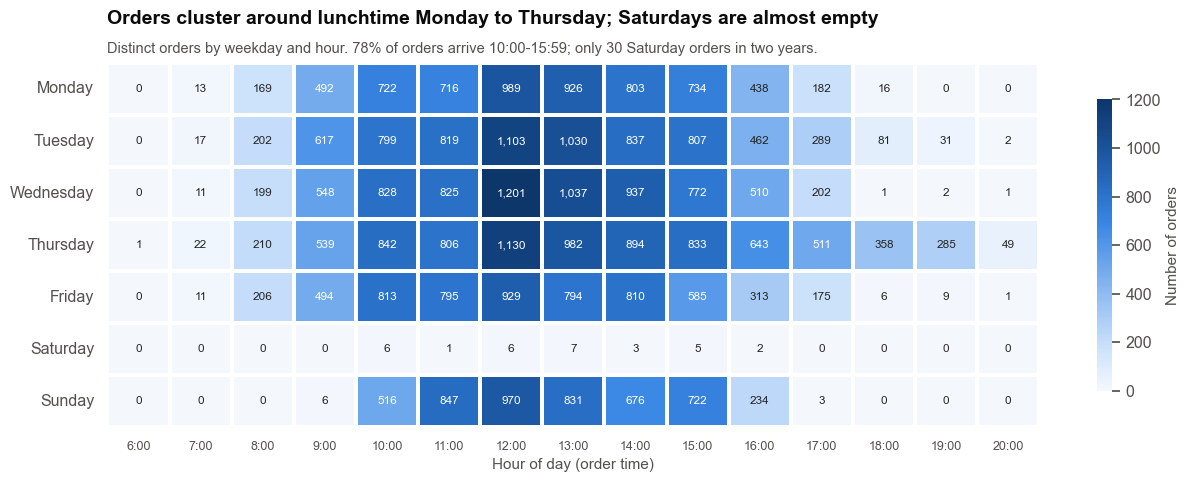

In [9]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heat, cmap=BLUE_RAMP, annot=True, fmt=",", annot_kws={"fontsize": 8.5},
            linewidths=1.5, linecolor="white", cbar_kws={"label": "Number of orders", "shrink": 0.8}, ax=ax)
ax.set_xlabel("Hour of day (order time)")
ax.set_ylabel("")
ax.set_xticklabels([f"{h}:00" for h in heat.columns], rotation=0, fontsize=9)
ax.tick_params(axis="y", rotation=0)
titles(ax, f"Orders cluster around lunchtime Monday to Thursday; Saturdays are almost empty",
       f"Distinct orders by weekday and hour. {midday:.0%} of orders arrive 10:00-15:59; "
       f"only {heat.loc['Saturday'].sum()} Saturday orders in two years.")
fig.tight_layout()
save_fig(fig, "04_weekday_hour_heatmap")
plt.show()

## 5. Order value distribution

In [10]:
order_values = sales.groupby("Invoice").agg(Value=("Revenue", "sum"), Type=("CustomerType", "first"))
ov = order_values.Value

print(ov.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99]).to_string())
print(f"\nMedian order: £{ov.median():,.2f}   Mean order: £{ov.mean():,.2f}")
big = ov >= 1000
print(f"Orders of £1,000+: {big.mean():.1%} of orders but {ov[big].sum() / ov.sum():.1%} of revenue")
order_values.groupby("Type").Value.median()

count   39,251.00
mean       485.14
std      1,095.15
min          0.19
10%         63.25
25%        149.41
50%        299.70
75%        481.02
90%        898.14
99%      4,033.82
max     52,940.94

Median order: £299.70   Mean order: £485.14
Orders of £1,000+: 8.5% of orders but 43.1% of revenue


Type
Guest        183.79
Registered   301.28
Name: Value, dtype: float64

saved 05_order_value_distribution.png


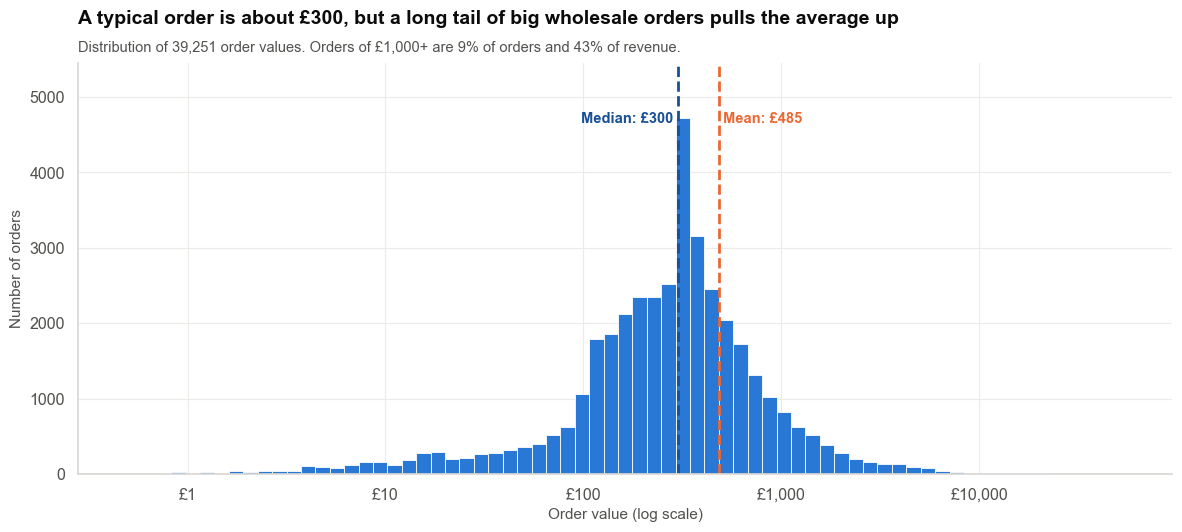

In [11]:
fig, ax = plt.subplots(figsize=(12, 5.5))
bins = np.logspace(np.log10(max(ov.min(), 0.5)), np.log10(ov.max()), 70)
ax.hist(ov, bins=bins, color=BLUE, edgecolor="white", linewidth=0.6)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"£{x:,.0f}"))

for value, label, color, offset in [(ov.median(), "Median", DARK_BLUE, -6), (ov.mean(), "Mean", ORANGE, 6)]:
    ax.axvline(value, color=color, lw=2, ls="--")
    ax.text(value, ax.get_ylim()[1] * 0.97, f" {label}: £{value:,.0f} ", color=color, fontweight="bold",
            ha="right" if offset < 0 else "left", va="top", fontsize=10.5)

ax.set_ylim(0, ax.get_ylim()[1] * 1.1)
ax.set_xlabel("Order value (log scale)")
ax.set_ylabel("Number of orders")
titles(ax, f"A typical order is about £{ov.median():,.0f}, but a long tail of big wholesale orders pulls the average up",
       f"Distribution of {len(ov):,} order values. Orders of £1,000+ are {big.mean():.0%} of orders "
       f"and {ov[big].sum() / ov.sum():.0%} of revenue.")
fig.tight_layout()
save_fig(fig, "05_order_value_distribution")
plt.show()

## Key Takeaways

- **Revenue was £19.04M over two years** from 39,251 orders. The year to Nov 2011 grew only **+1.7%** on the year before (£9.38M vs £9.22M), so the business is flat rather than growing.
- **The business is very seasonal.** September to November brings in **37.6%** of annual revenue. November is the biggest month both years (£1.40M in 2010, **£1.44M in 2011**), almost three times the low point (£505k in Feb 2011).
- **No single product dominates.** The top 10 products are only **7.6%** of revenue across 4,716 products. The Regency 3-tier cake stand is the biggest earner (£323k). The White Hanging Heart T-light holder, Jumbo Bag Red Retrospot, Assorted Colour Bird Ornament and Small Popcorn Holder are in the top 10 for both revenue and units.
- **The UK is 85.4% of revenue.** Outside it, revenue is very concentrated: Ireland brings in £606k from just **3 customers**, and the Netherlands brings in £546k from 22.
- **This is a weekday, office-hours business.** 78% of orders arrive between 10:00 and 15:59. Thursday is the busiest day (8,105 orders) and there were only 30 Saturday orders in two years.
- **The median order is £300 but the mean is £485.** Orders of £1,000 or more are just 8.5% of orders but **43.1% of revenue**, which points to a wholesale customer base. Guest orders are smaller (median £184 vs £301 for registered customers).